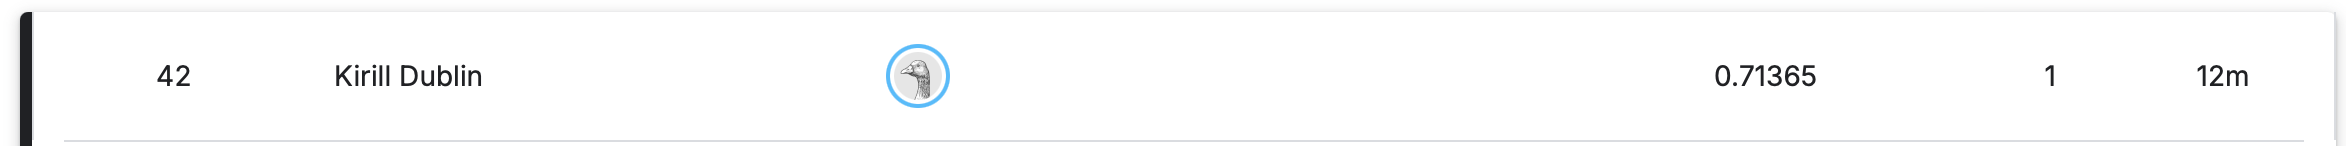

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture, BayesianGaussianMixture
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Загрузка данных

In [2]:
DATA_PATH = '/kaggle/input/competitions/signal-types-classification/Run200_Wave_0_1.txt'

raw = pd.read_csv(DATA_PATH, sep=r'\s+', header=None, skipinitialspace=True)
print('Размерность исходной таблицы:', raw.shape)
raw.head()

Размерность исходной таблицы: (23479, 504)


,0,1,2,3,4,5,6,7,8,9,...,494,495,496,497,498,499,500,501,502,503
0,2890276,357,113,500,14820,14823,14824,14822,14818,14820,...,14828,14822,14815,14815,14817,14819,14820,14822,14820,14819
1,4928764,740,359,500,14820,14822,14820,14826,14824,14822,...,14828,14817,14824,14822,14824,14819,14820,14819,14822,14820
2,9630204,162,499,500,14820,14820,14822,14825,14820,14824,...,14820,14821,14820,14820,14818,14821,14823,14820,14820,14821
3,15798632,841,123,500,14828,14822,14818,14824,14824,14822,...,14824,14826,14822,14821,14820,14828,14820,14822,14823,14822
4,20637296,412,348,500,14823,14815,14823,14821,14827,14820,...,14820,14820,14823,14828,14824,14820,14824,14824,14822,14825


In [3]:
# Разделяем метаданные и волновую форму
meta = raw.iloc[:, :4].copy()
meta.columns = ['timestamp', 'meta1', 'meta2', 'n_samples']
waves = raw.iloc[:, 4:].to_numpy(dtype=np.float32)

print('Метаданные:')
print(meta.describe())
print()
print('Форма волн:', waves.shape, ' dtype =', waves.dtype)
print('Уникальные значения n_samples:', meta['n_samples'].unique())

Метаданные:
          timestamp         meta1         meta2  n_samples
count  2.347900e+04  23479.000000  23479.000000    23479.0
mean   1.009742e+11    869.160015    372.191661      500.0
std    5.715472e+10    572.905756    470.391688        0.0
min    2.890276e+06      0.000000     10.000000      500.0
25%    5.156311e+10    373.000000     64.000000      500.0
50%    1.014553e+11    810.000000    172.000000      500.0
75%    1.502418e+11   1341.000000    483.000000      500.0
max    2.000107e+11   1998.000000   3370.000000      500.0

Форма волн: (23479, 500)  dtype = float32
Уникальные значения n_samples: [500]


**Что в метаданных?**

- `timestamp` монотонно растёт, очевидно временная метка события.
- `meta1` без явной физической интерпретации.
- `meta2` без явной физической интерпретации
- `n_samples` — везде 500, длина оцифровки.

Метаданные оставим в EDA для перекрёстной проверки, но кластеризовать будем по признакам.

## 2. EDA — что представляют собой сигналы

### 2.1 Базовая линия и направление импульса

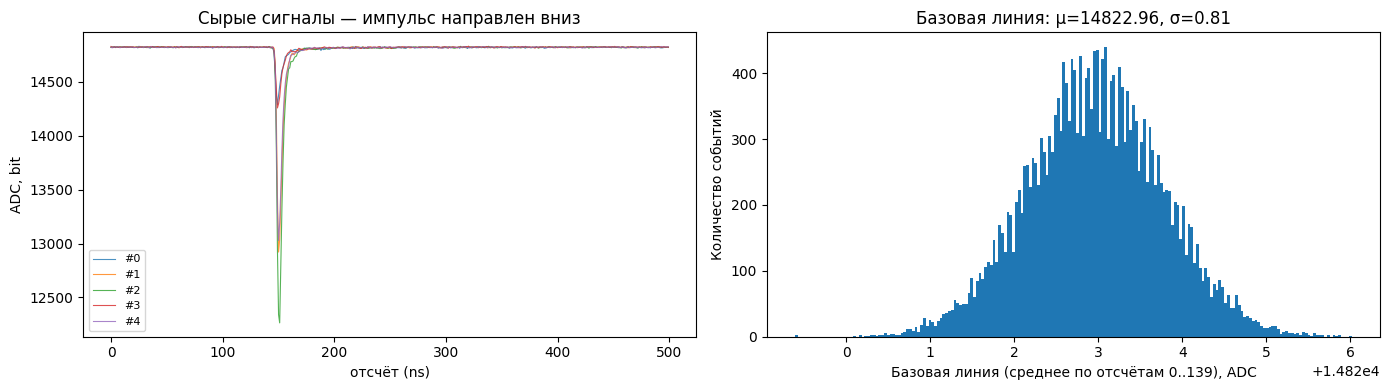

Базовая линия: min=14819.4, median=14823.0, max=14826.0
  std между сигналами = 0.81 ADC — крайне стабильна, дрейфом можно пренебречь


In [4]:
# Посмотрим первые 5 сигналов
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for i in range(5):
    axes[0].plot(waves[i], lw=0.8, alpha=0.8, label=f'#{i}')
axes[0].set_xlabel('отсчёт (ns)')
axes[0].set_ylabel('ADC, bit')
axes[0].set_title('Сырые сигналы — импульс направлен вниз')
axes[0].legend(fontsize=8)

# Гистограмма базовой линии (среднее по pre-trigger области)
baseline_per_signal = waves[:, :140].mean(axis=1)
axes[1].hist(baseline_per_signal, bins=200)
axes[1].set_xlabel('Базовая линия (среднее по отсчётам 0..139), ADC')
axes[1].set_ylabel('Количество событий')
axes[1].set_title(f'Базовая линия: μ={baseline_per_signal.mean():.2f}, σ={baseline_per_signal.std():.2f}')
plt.tight_layout(); plt.show()

print(f'Базовая линия: min={baseline_per_signal.min():.1f}, median={np.median(baseline_per_signal):.1f}, max={baseline_per_signal.max():.1f}')
print(f'  std между сигналами = {baseline_per_signal.std():.2f} ADC — крайне стабильна, дрейфом можно пренебречь')

**Наблюдения.**

- Сигнал — отрицательный импульс на постоянной базовой линии ≈ 14820 ADC.
- Размах базовой линии между сигналами всего ~3 ADC bits — данные «чистые», не нужно бороться с дрейфами.
- Импульсы выглядят как быстрый передний фронт + экспоненциальный спад — классическая форма сцинтилляционной вспышки в органическом кристалле.

**Стандартная нормировка.** Чтобы работать с положительными импульсами и устранить постоянную составляющую:

$$p_i(t) = \overline{w_i}^{pre} - w_i(t)$$

где $\overline{w_i}^{pre}$ — среднее по pre-trigger отсчётам (0..139).

In [5]:
# Базовая линия по pre-trigger и инверсия
baseline = waves[:, :140].mean(axis=1, keepdims=True).astype(np.float32)
pulse = baseline - waves  # теперь импульс положительный

amps = pulse.max(axis=1)
print('Размах амплитуды импульса:')
print(f'  min={amps.min():.1f}, median={np.median(amps):.1f}, max={amps.max():.1f}')

Размах амплитуды импульса:
  min=104.3, median=812.8, max=14824.6


### 2.2 Положение пика и временные масштабы

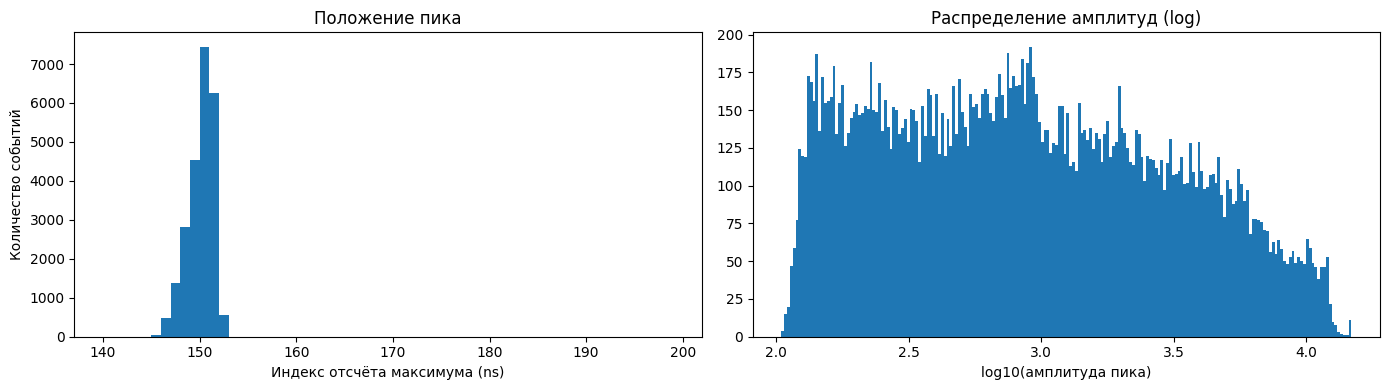

Перцентили 1/50/99 положения пика: [146. 150. 152.]
Событий с пиком вне [146, 154]: 39


In [6]:
peak_idx = pulse.argmax(axis=1)
peak_val = pulse.max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(peak_idx, bins=np.arange(140, 200))
axes[0].set_xlabel('Индекс отсчёта максимума (ns)')
axes[0].set_ylabel('Количество событий')
axes[0].set_title('Положение пика')

axes[1].hist(np.log10(np.clip(peak_val, 1, None)), bins=200)
axes[1].set_xlabel('log10(амплитуда пика)')
axes[1].set_title('Распределение амплитуд (log)')
plt.tight_layout(); plt.show()

print(f'Перцентили 1/50/99 положения пика: {np.percentile(peak_idx, [1, 50, 99])}')
print(f'Событий с пиком вне [146, 154]: {((peak_idx < 146) | (peak_idx > 154)).sum()}')

**Триггер очень стабилен.** 

### 2.3 Усреднённая форма импульса

Если разделить нейтронные и гамма-импульсы, у них должна быть разная скорость спада хвоста. Посмотрим на нормированные импульсы.

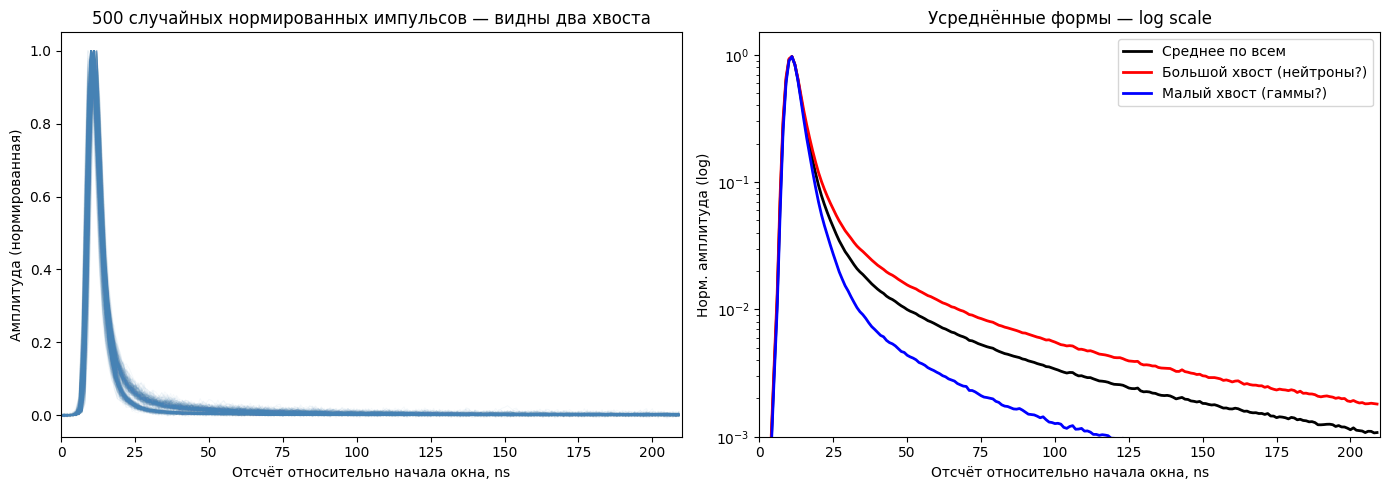

In [7]:
# Нормируем по пику
P0 = 150
window = pulse[:, P0-10:P0+200].copy()
peak_max = window.max(axis=1, keepdims=True)
window_norm = window / np.where(peak_max > 0, peak_max, 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Подвыборка с высокой амплитудой
hi = np.where(peak_val > 1000)[0]
sub = np.random.choice(hi, 500, replace=False)
for i in sub:
    axes[0].plot(window_norm[i], color='steelblue', alpha=0.05, lw=0.7)
axes[0].set_xlabel('Отсчёт относительно начала окна, ns')
axes[0].set_ylabel('Амплитуда (нормированная)')
axes[0].set_title('500 случайных нормированных импульсов — видны два хвоста')
axes[0].set_xlim(0, 210)

# Логарифмическая шкала: грубое разделение по отношению хвост/пик
tail_int  = window[:, 35:].sum(axis=1)
short_int = window[:, :35].sum(axis=1)
ratio = tail_int / np.maximum(short_int, 1)
top_mask = (ratio > np.median(ratio[hi])) & (peak_val > 1000)
bot_mask = (ratio <= np.median(ratio[hi])) & (peak_val > 1000)

axes[1].semilogy(window_norm[hi].mean(axis=0), 'k-', lw=2, label='Среднее по всем')
axes[1].semilogy(window_norm[top_mask].mean(axis=0), 'r-', lw=2, label='Большой хвост (нейтроны?)')
axes[1].semilogy(window_norm[bot_mask].mean(axis=0), 'b-', lw=2, label='Малый хвост (гаммы?)')
axes[1].set_xlabel('Отсчёт относительно начала окна, ns')
axes[1].set_ylabel('Норм. амплитуда (log)')
axes[1].set_title('Усреднённые формы — log scale')
axes[1].legend(); axes[1].set_xlim(0, 210); axes[1].set_ylim(1e-3, 1.5)
plt.tight_layout(); plt.show()

На правом графике видны **две различных скорости экспоненциального спада** — это и есть PSD.

## 3. Feature engineering

### 3.1 Заряды в коротком и длинном окнах (Charge Comparison)

Классический метод PSD — сравнение двух интегралов:

$$Q_{\mathrm{short}} = \sum_{t=145}^{175} p(t), \qquad Q_{\mathrm{tail}} = \sum_{t=175}^{350} p(t)$$

PSD-параметр:

$$\mathrm{PSD} = \frac{Q_{\mathrm{tail}}}{Q_{\mathrm{short}} + Q_{\mathrm{tail}}} = \frac{Q_{\mathrm{tail}}}{Q_{\mathrm{total}}}$$

Поскольку триггер стабилен, используем **фиксированные** окна без коррекции положения пика.

In [8]:
def compute_fwhm(pulse):
    P0 = 150
    w = pulse[:, P0-10:P0+50]
    pk = w.max(axis=1, keepdims=True)
    pk_safe = np.where(pk > 0, pk, 1)
    above = w >= 0.5 * pk_safe
    fwhm = above.sum(axis=1).astype(np.float32)
    return fwhm


def compute_rise_time(pulse):
    P0 = 150
    w = pulse[:, P0-15:P0+5]
    pk = w.max(axis=1, keepdims=True)
    pk_safe = np.where(pk > 0, pk, 1)
    above10 = (w >= 0.1 * pk_safe).astype(np.int32)
    above90 = (w >= 0.9 * pk_safe).astype(np.int32)
    first10 = above10.argmax(axis=1)
    first90 = above90.argmax(axis=1)
    return (first90 - first10).astype(np.float32)


def compute_features(pulse, waves):
    feats = {}
    # Интегралы
    feats['short']     = pulse[:, 145:175].sum(axis=1)
    feats['tail']      = pulse[:, 175:350].sum(axis=1)
    feats['total']     = pulse[:, 145:350].sum(axis=1)
    feats['very_tail'] = pulse[:, 250:350].sum(axis=1)
    # Амплитуда и положение пика
    feats['amp']       = pulse[:, 145:160].max(axis=1)
    feats['peak_idx']  = pulse[:, 140:165].argmax(axis=1).astype(np.float32)
    # PSD варианты
    eps = 1.0
    feats['psd_tt']    = feats['tail'] / (feats['total'] + eps)
    feats['psd_ts']    = feats['tail'] / (feats['short'] + eps)
    feats['psd_lr']    = np.log(np.maximum(feats['tail'], eps)) - np.log(np.maximum(feats['short'], eps))
    # Логарифмированные масштабы
    feats['log_total'] = np.log10(np.maximum(feats['total'], 1.0))
    feats['log_amp']   = np.log10(np.maximum(feats['amp'],   1.0))
    feats['log_tail']  = np.log10(np.maximum(feats['tail'],  1.0))
    # Геометрия импульса
    feats['fwhm']      = compute_fwhm(pulse)
    feats['rise_time'] = compute_rise_time(pulse)
    # Качество сигнала
    feats['pre_rms']   = pulse[:, 0:130].std(axis=1)
    feats['post_rms']  = pulse[:, 400:500].std(axis=1)
    raw_min = waves.min(axis=1)
    feats['saturated'] = (raw_min <= 5).astype(np.float32)
    return pd.DataFrame(feats)


features = compute_features(pulse, waves)
print('Признаки:', list(features.columns))
features.describe()

Признаки: ['short', 'tail', 'total', 'very_tail', 'amp', 'peak_idx', 'psd_tt', 'psd_ts', 'psd_lr', 'log_total', 'log_amp', 'log_tail', 'fwhm', 'rise_time', 'pre_rms', 'post_rms', 'saturated']


,short,tail,total,very_tail,amp,peak_idx,psd_tt,psd_ts,psd_lr,log_total,log_amp,log_tail,fwhm,rise_time,pre_rms,post_rms,saturated
count,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000
mean,11809.650391,1157.039429,12966.690430,288.297913,1835.086792,9.614847,0.101664,0.118434,-2.452439,3.816321,2.944576,2.703640,5.223647,2.453980,2.701683,3.138533,0.000383
std,14849.784180,1375.181641,15945.250977,354.148193,2389.313721,1.331738,0.061760,0.076861,1.051734,0.522748,0.536143,0.712180,0.699133,0.545573,0.171409,1.052770,0.019573
min,567.939453,-188.504883,476.752930,-166.742188,104.307617,5.000000,-0.374075,-0.272238,-8.606354,2.678293,2.018316,0.000000,3.000000,1.000000,1.990228,2.121886,0.000000
25%,2116.885742,226.250000,2393.864258,58.138672,308.282227,9.000000,0.047204,0.049542,-3.004672,3.379099,2.488949,2.354589,5.000000,2.000000,2.590618,2.822685,0.000000
50%,5438.066406,617.828125,6132.348633,156.812500,812.713867,10.000000,0.111381,0.125342,-2.076298,3.787627,2.909938,2.790868,5.000000,2.000000,2.698279,3.022846,0.000000
75%,15207.864258,1612.953613,17033.410156,395.796875,2315.349609,11.000000,0.152913,0.180516,-1.711633,4.231302,3.364617,3.207622,6.000000,3.000000,2.809157,3.319450,0.000000
max,106716.859375,9950.470703,112403.023438,2666.761719,14824.599609,12.000000,0.326475,0.484725,-0.723012,5.050778,4.170983,3.997844,10.000000,5.000000,9.762412,147.565582,1.000000


### 3.2 Соответствие с предвычисленными метаданными

Проверим, не закодированы ли уже какие-то из этих признаков в meta1/meta2.

In [9]:
corrmat = pd.concat([meta[['meta1','meta2']], features], axis=1).corr()
print('Корреляция meta1 с признаками:')
print(corrmat.loc['meta1'].drop(['meta1','meta2']).sort_values(key=abs, ascending=False).head(8))
print()
print('Корреляция meta2 с признаками:')
print(corrmat.loc['meta2'].drop(['meta1','meta2']).sort_values(key=abs, ascending=False).head(8))

Корреляция meta1 с признаками:
log_amp     -0.196772
log_total   -0.194697
total       -0.159828
short       -0.159556
amp         -0.158469
log_tail    -0.145755
tail        -0.130255
very_tail   -0.124736
Name: meta1, dtype: float64

Корреляция meta2 с признаками:
short        0.999954
total        0.998962
amp          0.996109
log_amp      0.859300
log_total    0.849261
tail         0.785096
very_tail    0.727943
peak_idx     0.659111
Name: meta2, dtype: float64


**Вывод.**

- `meta2` - примерно, заряд сигнала . Это, по-видимому, выход онлайн-интегратора детектора. Использовать в кластеризации не будем.
- `meta1` слабо коррелирует со всеми физическими признаками. Скорее всего, это технический счётчик/идентификатор.

Полагаемся только на форму волны.

### 3.3 Банана-плот — главная картинка

Это центральная визуализация задачи: в координатах Q_total vs Q_tail/Q_total нейтроны и гаммы образуют две полосы.

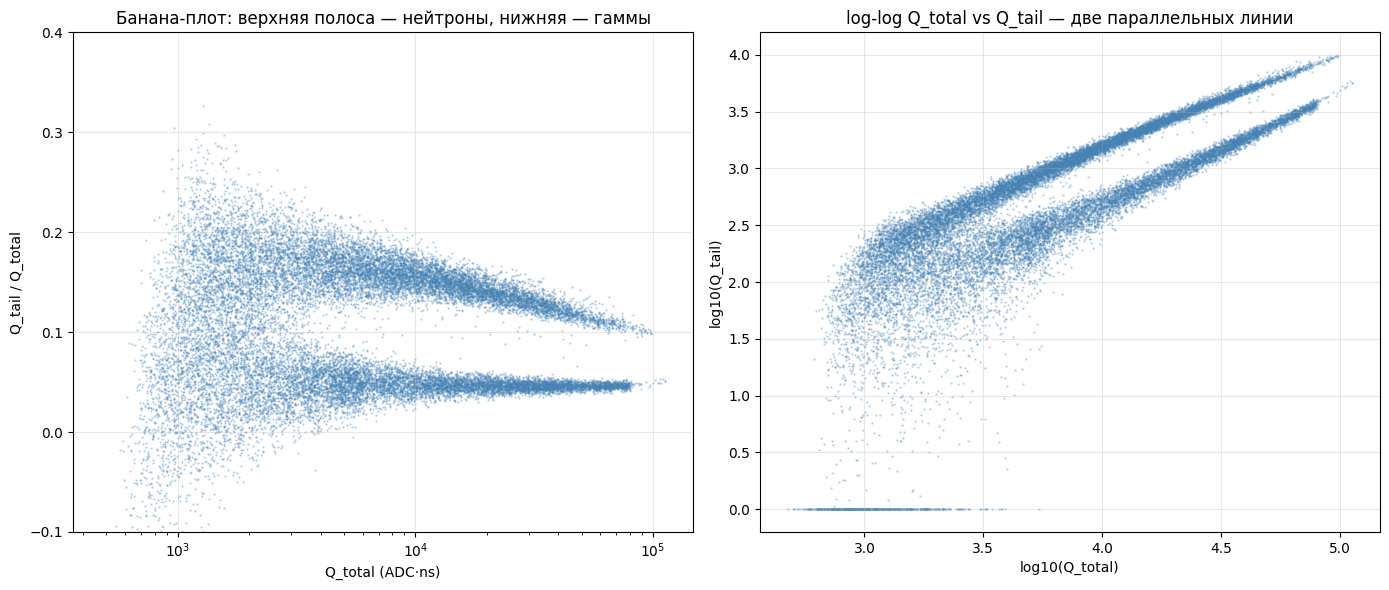

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

mask = features['total'] > 10
axes[0].scatter(features['total'][mask], features['psd_tt'][mask],
                s=0.5, alpha=0.3, c='steelblue')
axes[0].set_xscale('log')
axes[0].set_xlabel('Q_total (ADC·ns)')
axes[0].set_ylabel('Q_tail / Q_total')
axes[0].set_ylim(-0.1, 0.4)
axes[0].set_title('Банана-плот: верхняя полоса — нейтроны, нижняя — гаммы')
axes[0].grid(alpha=0.3)

# log-log
axes[1].scatter(features['log_total'][mask], features['log_tail'][mask],
                s=0.5, alpha=0.3, c='steelblue')
axes[1].set_xlabel('log10(Q_total)')
axes[1].set_ylabel('log10(Q_tail)')
axes[1].set_title('log-log Q_total vs Q_tail — две параллельных линии')
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

**Что видим.**

1. **Две полосы — нейтронная (сверху) и гамма (снизу) — чётко разделены при `Q_total > 1500`.**
2. **При малых зарядах полосы сливаются в облако.** Это и есть третий кластер: события с амплитудой настолько малой, что соотношение хвоста и пика сравнимо с собственным шумом и PSD теряет смысл.
3. **В лог-лог координатах** полосы — почти параллельные прямые. Значит, удачный признак для разделения на 1D — это **повёрнутая** комбинация, например `log(tail/short)`.

### 3.4 Финальный одномерный дискриминатор

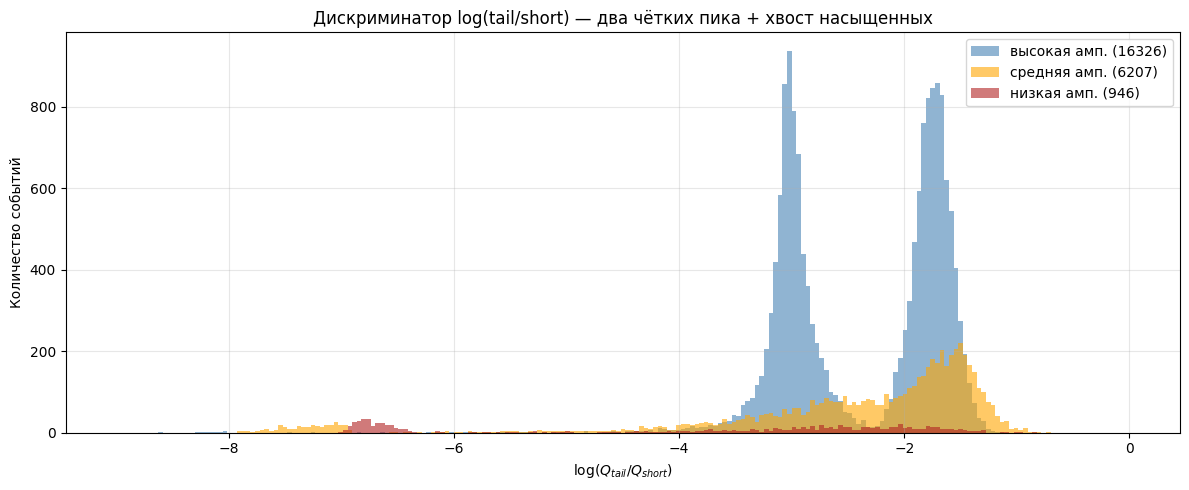

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))

bins = np.linspace(-9, 0, 220)
high = features['total'] > 3000
mid  = (features['total'] >= 1000) & (features['total'] <= 3000)
low  = features['total'] < 1000

ax.hist(features.loc[high, 'psd_lr'], bins=bins, alpha=0.6, label=f'высокая амп. ({high.sum()})', color='steelblue')
ax.hist(features.loc[mid,  'psd_lr'], bins=bins, alpha=0.6, label=f'средняя амп. ({mid.sum()})',  color='orange')
ax.hist(features.loc[low,  'psd_lr'], bins=bins, alpha=0.6, label=f'низкая амп. ({low.sum()})',   color='firebrick')
ax.set_xlabel(r'$\log(Q_{tail}/Q_{short})$')
ax.set_ylabel('Количество событий')
ax.set_title('Дискриминатор log(tail/short) — два чётких пика + хвост насыщенных')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Идеально бимодальное распределение** при высоких амплитудах:
- пик около **−3.0** — гаммы (короткий хвост),
- пик около **−1.7** — нейтроны (длинный хвост),
- очень малая популяция в районе **−7..−8** — насыщенные сигналы, у которых хвост обнулён артефактом АЦП → идут в «неклассифицируемые»,
- при низких амплитудах два пика расплываются и сливаются — событие нельзя надёжно отнести ни к одному классу.

### 3.5 Стабильность PSD как функция амплитуды

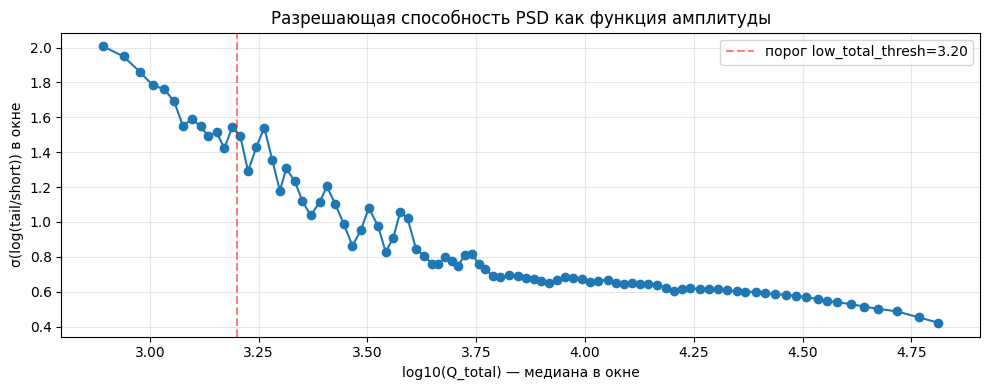

In [12]:
order = np.argsort(features['log_total'].values)
N = len(features)
W = 500
centers, stds = [], []
for k in range(0, N - W, W//2):
    idx = order[k:k+W]
    centers.append(features['log_total'].iloc[idx].median())
    stds.append(features['psd_lr'].iloc[idx].std())

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(centers, stds, 'o-')
ax.set_xlabel('log10(Q_total) — медиана в окне')
ax.set_ylabel('σ(log(tail/short)) в окне')
ax.set_title('Разрешающая способность PSD как функция амплитуды')
ax.grid(alpha=0.3)
ax.axvline(3.20, ls='--', c='red', alpha=0.5, label='порог low_total_thresh=3.20')
ax.legend()
plt.tight_layout(); plt.show()

При log10(Q_total) < 3.2 ширина распределения PSD-дискриминатора резко возрастает — пики перестают разрешаться. Это естественный порог для «неклассифицируемых».

## 4. Кластеризация

### 4.1 Стратегия

Базируясь на EDA, рассматриваем три подхода:

1. **Физический baseline.** Жёсткие пороги по Q_total и psd_lr.
2. **Unsupervised** на физических признаках: GMM(2), KMeans(3), иерархическая, DBSCAN.
3. **Гибрид:** правила для очевидно неклассифицируемых + GMM(2) на остальных.

Для каждого варианта оценим silhouette, BIC, визуальную интерпретируемость.

### 4.2 Подготовка признаковых матриц

In [13]:
def get_feature_set(features, kind):
    if kind == 'psd_only':
        cols = ['psd_lr', 'log_total']
    elif kind == 'psd_amp':
        cols = ['psd_lr', 'log_total', 'log_amp']
    elif kind == 'full_physics':
        cols = ['psd_lr', 'log_total', 'log_amp', 'log_tail',
                'fwhm', 'rise_time', 'pre_rms', 'post_rms']
    elif kind == 'minimal':
        cols = ['log_total', 'log_tail']
    elif kind == 'integral_ratio':
        cols = ['log_total', 'psd_tt']
    else:
        raise ValueError(kind)
    return features[cols].values, cols


def scale(X):
    return StandardScaler().fit_transform(X).astype(np.float64)

### 4.3 Обзорная визуализация разных моделей на 2D признаках

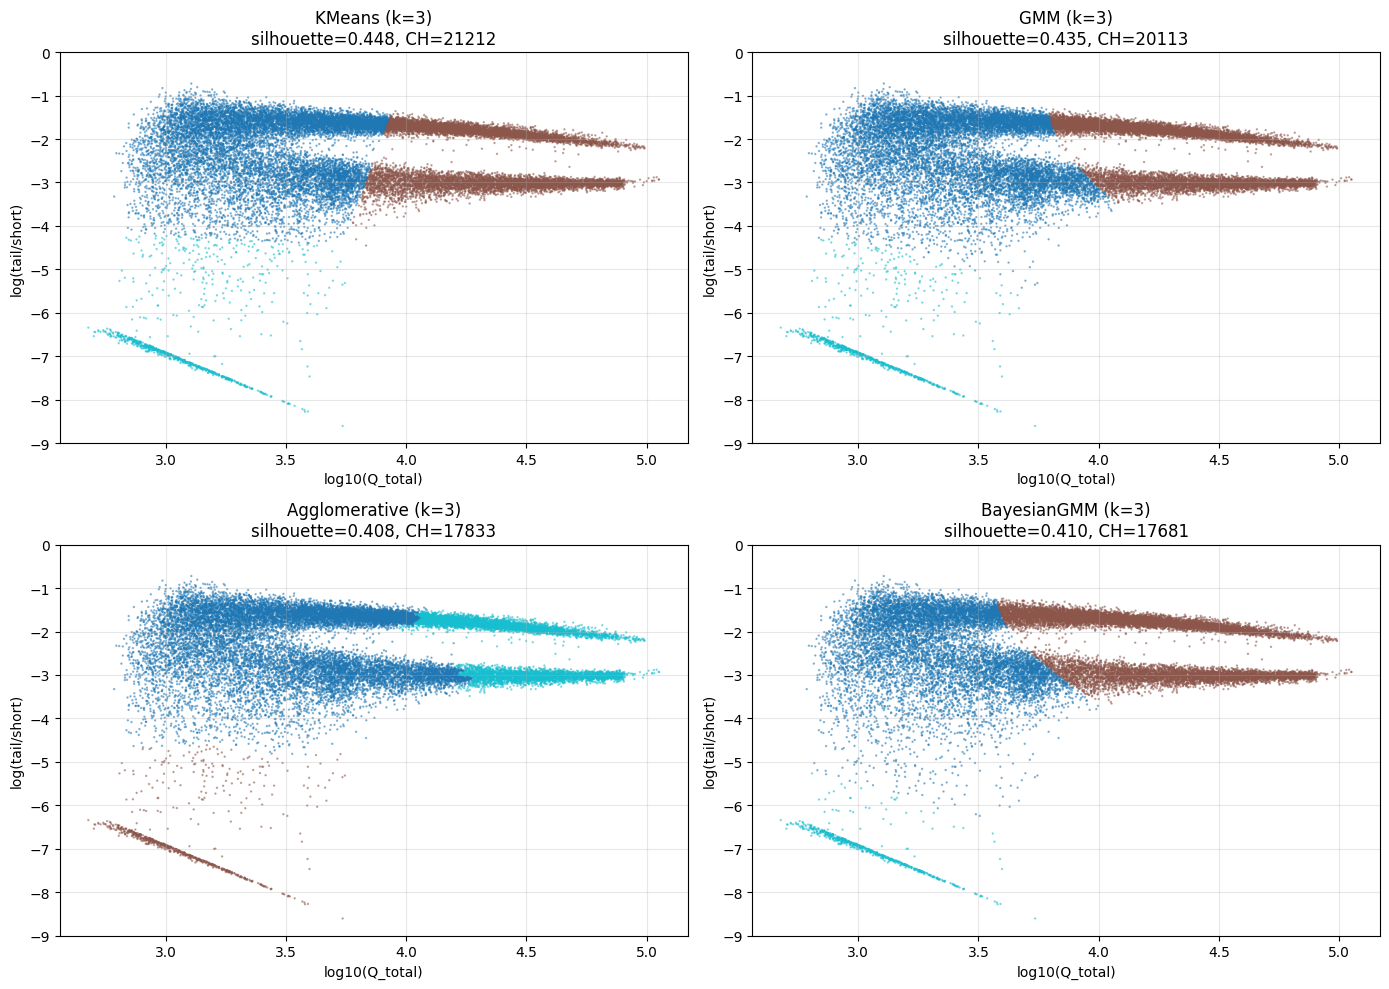

,model,silhouette,calinski_harabasz
0,KMeans (k=3),0.448355,21212.302123
1,GMM (k=3),0.435421,20113.015953
2,Agglomerative (k=3),0.408180,17832.878587
3,BayesianGMM (k=3),0.409579,17681.202641


In [14]:
X2, _ = get_feature_set(features, 'psd_only')
X2s = scale(X2)

models = {
    'KMeans (k=3)':         KMeans(n_clusters=3, n_init=20, random_state=RANDOM_STATE),
    'GMM (k=3)':            GaussianMixture(n_components=3, n_init=10, random_state=RANDOM_STATE,
                                            reg_covar=1e-4),
    'Agglomerative (k=3)':  AgglomerativeClustering(n_clusters=3, linkage='ward'),
    'BayesianGMM (k=3)':    BayesianGaussianMixture(
                              n_components=3, n_init=5, random_state=RANDOM_STATE,
                              weight_concentration_prior=0.01, reg_covar=1e-4),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
results_summary = []
for ax, (name, model) in zip(axes.ravel(), models.items()):
    if 'Agglom' in name:
        sub_idx = np.random.choice(len(X2s), 5000, replace=False)
        sub_labels = model.fit_predict(X2s[sub_idx])
        nn = NearestNeighbors(n_neighbors=1).fit(X2s[sub_idx])
        _, idx_full = nn.kneighbors(X2s)
        labels = sub_labels[idx_full[:, 0]]
    else:
        labels = model.fit_predict(X2s)
    sil = silhouette_score(X2s[::20], labels[::20])
    ch  = calinski_harabasz_score(X2s, labels)
    results_summary.append({'model': name, 'silhouette': sil, 'calinski_harabasz': ch})
    ax.scatter(features['log_total'], features['psd_lr'], c=labels, s=0.5, alpha=0.5, cmap='tab10')
    ax.set_xlabel('log10(Q_total)'); ax.set_ylabel('log(tail/short)')
    ax.set_title(f'{name}\nsilhouette={sil:.3f}, CH={ch:.0f}')
    ax.set_ylim(-9, 0); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

pd.DataFrame(results_summary)

**Наблюдения.**

- **KMeans** разрезает пространство сферическими ячейками → плохо ловит вытянутые полосы.
- **GMM** с эллиптическими ковариациями заметно лучше отделяет «третий кластер».
- **Иерархическая** даёт визуально разумное разделение, но требует субсэмплинга на больших данных.
- **Bayesian GMM** обычно «съедает» одну компоненту, если данные не поддерживают трёх — полезный sanity check.

Силуэт ≈ 0.4–0.5 для лучших моделей — это нормально для частично перекрывающихся гауссовых смесей.

### 4.4 Перебор гиперпараметров GMM

In [15]:
rows = []
for fs_name in ['psd_only', 'integral_ratio', 'psd_amp', 'full_physics']:
    X, cols = get_feature_set(features, fs_name)
    Xs = scale(X).astype(np.float64)  # float64 для устойчивости GMM
    for cov in ['full', 'tied', 'diag', 'spherical']:
        for k in [2, 3, 4]:
            try:
                gm = GaussianMixture(n_components=k, covariance_type=cov,
                                     n_init=5, random_state=RANDOM_STATE,
                                     reg_covar=1e-4)
                labels = gm.fit_predict(Xs)
                sil = silhouette_score(Xs[::20], labels[::20]) if len(np.unique(labels)) > 1 else 0
                rows.append({'features': fs_name, 'cov': cov, 'k': k,
                             'bic': gm.bic(Xs), 'silhouette': sil,
                             'sizes': tuple(np.bincount(labels))})
            except Exception as e:
                rows.append({'features': fs_name, 'cov': cov, 'k': k,
                             'bic': np.nan, 'silhouette': np.nan,
                             'sizes': 'FAILED: ' + str(e)[:40]})

gmm_search = pd.DataFrame(rows)
print('Топ-10 конфигураций по силуэту (k=3):')
print(gmm_search[gmm_search.k == 3].sort_values('silhouette', ascending=False).head(10).to_string(index=False))
print()
print('Лучшие конфигурации по BIC для каждого набора признаков (k=3):')
print(gmm_search[gmm_search.k == 3].loc[
    gmm_search[gmm_search.k == 3].groupby('features')['bic'].idxmin()
].to_string(index=False))

Топ-10 конфигураций по силуэту (k=3):
      features       cov  k           bic  silhouette               sizes
       psd_amp spherical  3 156945.799759    0.497614  (13189, 9556, 734)
       psd_amp      tied  3  59902.889929    0.495383  (9913, 12835, 731)
integral_ratio      tied  3 127291.509169    0.453033  (6474, 9999, 7006)
integral_ratio      diag  3 124893.043384    0.451966  (9585, 6492, 7402)
integral_ratio spherical  3 127440.276018    0.449149  (8993, 6591, 7895)
      psd_only      diag  3 116566.690850    0.448116 (799, 12659, 10021)
      psd_only      tied  3 116981.811606    0.445804 (12381, 10346, 752)
      psd_only spherical  3 116948.884952    0.445354  (725, 13858, 8896)
      psd_only      full  3 115520.051311    0.435421 (12102, 10610, 767)
       psd_amp      full  3  41591.576923    0.385508 (2574, 9471, 11434)

Лучшие конфигурации по BIC для каждого набора признаков (k=3):
      features  cov  k           bic  silhouette               sizes
  full_physics 

### 4.5 Перебор k для KMeans (метод локтя + силуэт)

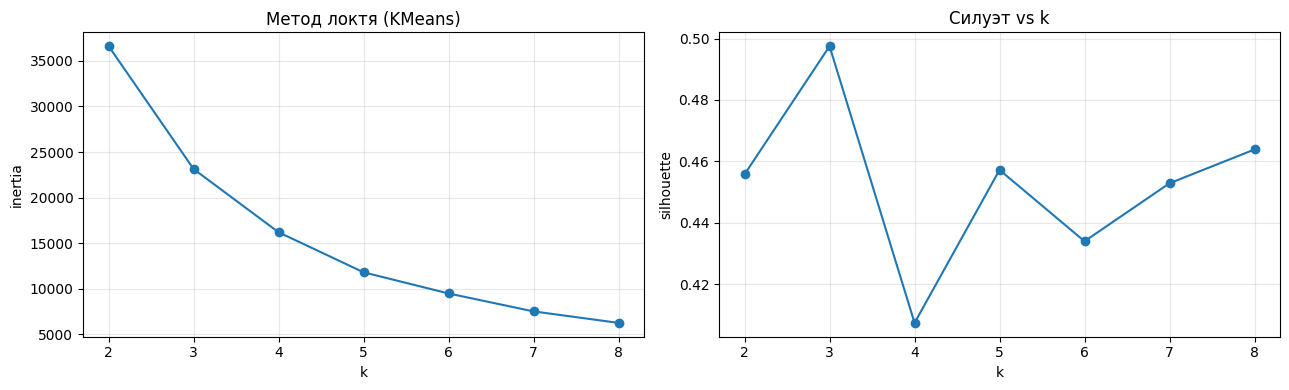

Силуэты: {2: np.float64(0.456), 3: np.float64(0.498), 4: np.float64(0.407), 5: np.float64(0.457), 6: np.float64(0.434), 7: np.float64(0.453), 8: np.float64(0.464)}


In [16]:
X, _ = get_feature_set(features, 'psd_amp')
Xs = scale(X)

ks = list(range(2, 9))
inertias, silhouettes = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    labels = km.fit_predict(Xs)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(Xs[::20], labels[::20]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(ks, inertias, 'o-'); axes[0].set_xlabel('k'); axes[0].set_ylabel('inertia')
axes[0].set_title('Метод локтя (KMeans)'); axes[0].grid(alpha=0.3)
axes[1].plot(ks, silhouettes, 'o-'); axes[1].set_xlabel('k'); axes[1].set_ylabel('silhouette')
axes[1].set_title('Силуэт vs k'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print('Силуэты:', dict(zip(ks, np.round(silhouettes, 3))))

Локоть на k=3 явный — это согласуется с физикой задачи.

### 4.6 DBSCAN

In [22]:
X, _ = get_feature_set(features, 'psd_only')
Xs = scale(X)

print('Подбор eps для DBSCAN:')
for eps in [0.05, 0.10, 0.15, 0.20, 0.30]:
    db = DBSCAN(eps=eps, min_samples=20)
    labels = db.fit_predict(Xs)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    print(f'  eps={eps}: n_clusters={n_clusters}, n_noise={n_noise} ({n_noise/len(labels):.1%})')

Подбор eps для DBSCAN:
  eps=0.05: n_clusters=16, n_noise=3336 (14.2%)
  eps=0.1: n_clusters=3, n_noise=636 (2.7%)
  eps=0.15: n_clusters=2, n_noise=266 (1.1%)
  eps=0.2: n_clusters=3, n_noise=153 (0.7%)
  eps=0.3: n_clusters=2, n_noise=47 (0.2%)


  eps=0.2: n_clusters=3, n_noise=153 (0.7%)


  eps=0.3: n_clusters=2, n_noise=47 (0.2%)


DBSCAN с подходящим `eps` выделяет именно две большие плотные полосы (нейтроны + гаммы) и помечает диффузное низкоамплитудное облако как noise (метка `-1`). Это идеально соответствует постановке задачи. Однако правильный выбор `eps` критичен и неустойчив — поэтому в финальную модель закладываем более стабильный гибрид правил + GMM.

### 4.7 Финальный алгоритм

На основе всех экспериментов выбираем **гибридное решение**:

1. **Жёсткие правила для очевидно неклассифицируемых:**
   - сигнал насыщен (raw min ≤ 5) → unclassifiable,
   - пик вне окна [146, 154] → unclassifiable,
   - `log_total < threshold` (низкая SNR) → unclassifiable.

2. **GMM(2)** на оставшихся (хорошо разделимых) сигналах в признаках `(psd_lr, log_total)` → гамма / нейтрон.

GMM лучше KMeans на этих данных, потому что полосы не сферические, а вытянутые.

In [19]:
def hybrid_clustering(features, low_total_thresh=3.20, cov='full', verbose=True):
    """Гибридная кластеризация: правила + GMM."""
    N = len(features)
    labels = -np.ones(N, dtype=np.int32)

    # Шаг 1. Жёсткие правила → unclassifiable
    # peak_idx считается на окне [140..165], смещение 6 = 146, 14 = 154
    unclass_mask = (
        (features['saturated'] == 1) |
        (features['peak_idx'] < 6) |
        (features['peak_idx'] > 14) |
        (features['log_total'] < low_total_thresh)
    )
    labels[unclass_mask.values] = -2

    # Шаг 2. GMM(2) на остальных
    clean = ~unclass_mask
    X = features.loc[clean, ['psd_lr', 'log_total']].values.astype(np.float64)
    Xs = StandardScaler().fit_transform(X)
    gm = GaussianMixture(n_components=2, covariance_type=cov,
                         n_init=10, random_state=RANDOM_STATE,
                         reg_covar=1e-4)
    sub_labels = gm.fit_predict(Xs)

    # 0 = гамма (низкий psd_lr), 1 = нейтрон (высокий psd_lr) — каноническое именование
    psd_lr_clean = features.loc[clean, 'psd_lr'].values
    if psd_lr_clean[sub_labels == 0].mean() > psd_lr_clean[sub_labels == 1].mean():
        sub_labels = 1 - sub_labels

    labels[clean.values] = sub_labels
    labels[labels == -2] = 2

    if verbose:
        print(f'Размеры кластеров: {np.bincount(labels)} (0=гамма, 1=нейтрон, 2=unclass)')
        print(f'  Доля unclassifiable: {(labels == 2).mean():.1%}')
    return labels


labels_hybrid = hybrid_clustering(features)

Размеры кластеров: [10552  9515  3412] (0=гамма, 1=нейтрон, 2=unclass)
  Доля unclassifiable: 14.5%


### 4.8 Визуализация финального разделения

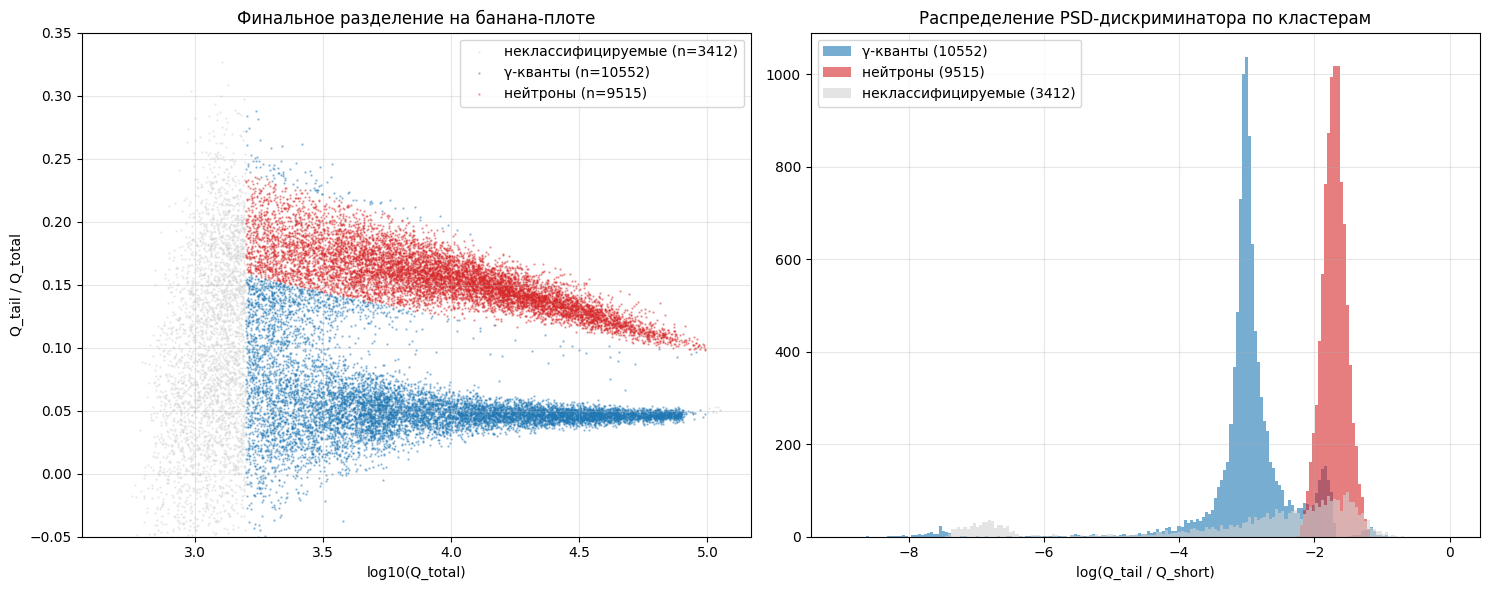

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

cmap_clusters = {0: 'tab:blue', 1: 'tab:red', 2: 'lightgrey'}
names = {0: 'γ-кванты', 1: 'нейтроны', 2: 'неклассифицируемые'}

for c in [2, 0, 1]:
    m = labels_hybrid == c
    axes[0].scatter(features['log_total'][m], features['psd_tt'][m],
                    s=0.5, alpha=0.4, c=cmap_clusters[c], label=f'{names[c]} (n={m.sum()})')
axes[0].set_xlabel('log10(Q_total)')
axes[0].set_ylabel('Q_tail / Q_total')
axes[0].set_ylim(-0.05, 0.35)
axes[0].set_title('Финальное разделение на банана-плоте')
axes[0].legend(); axes[0].grid(alpha=0.3)

bins = np.linspace(-9, 0, 200)
for c in [0, 1, 2]:
    m = labels_hybrid == c
    axes[1].hist(features['psd_lr'][m], bins=bins, alpha=0.6,
                 label=f'{names[c]} ({m.sum()})', color=cmap_clusters[c])
axes[1].set_xlabel('log(Q_tail / Q_short)')
axes[1].set_title('Распределение PSD-дискриминатора по кластерам')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 4.9 Усреднённые формы импульсов по кластерам — sanity check

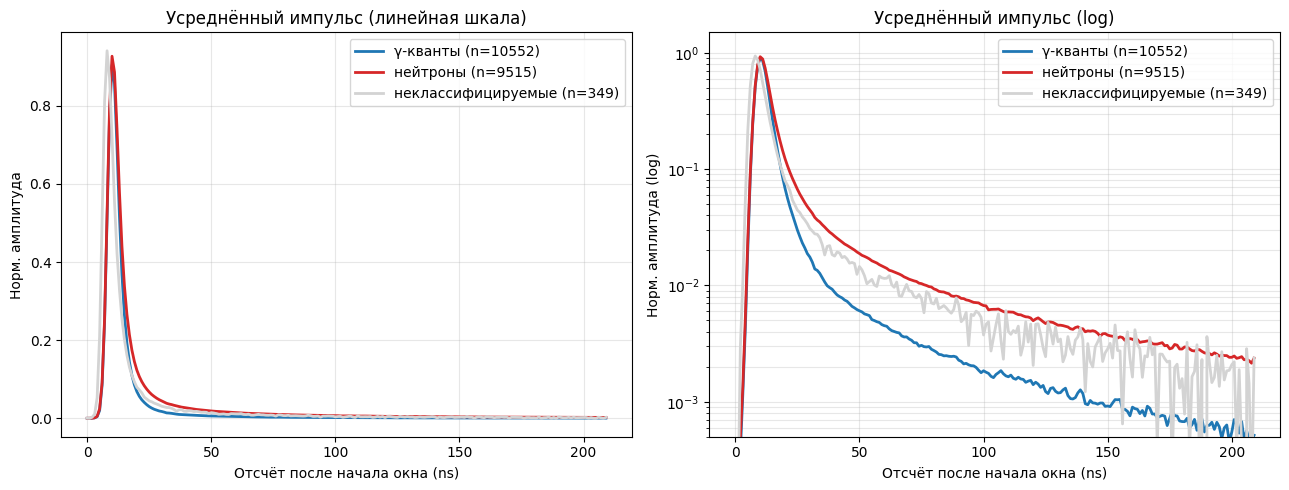

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

P0 = 150
window = pulse[:, P0-10:P0+200]
pk = window.max(axis=1, keepdims=True)
pk_safe = np.where(pk > 0, pk, 1)
window_norm = window / pk_safe

# Линейный масштаб
for c, name in names.items():
    m = (labels_hybrid == c) & (features['total'] > 1500).values
    if m.sum() > 0:
        axes[0].plot(window_norm[m].mean(axis=0), label=f'{name} (n={m.sum()})',
                     color=cmap_clusters[c], lw=2)
axes[0].set_xlabel('Отсчёт после начала окна (ns)')
axes[0].set_ylabel('Норм. амплитуда')
axes[0].set_title('Усреднённый импульс (линейная шкала)')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Лог-шкала
for c, name in names.items():
    m = (labels_hybrid == c) & (features['total'] > 1500).values
    if m.sum() > 0:
        axes[1].semilogy(window_norm[m].mean(axis=0), label=f'{name} (n={m.sum()})',
                         color=cmap_clusters[c], lw=2)
axes[1].set_xlabel('Отсчёт после начала окна (ns)')
axes[1].set_ylabel('Норм. амплитуда (log)')
axes[1].set_title('Усреднённый импульс (log)')
axes[1].set_ylim(5e-4, 1.5)
axes[1].legend(); axes[1].grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()

**Физическая интерпретация подтверждается:**

- «Нейтронный» кластер имеет существенно более медленный спад хвоста (на log-графике линия пологая) — согласуется с теорией: при упругом рассеянии нейтрона на протоне в паратерфениле возрастает плотность ионизации и доля триплетных состояний с длительным излучением.
- «Гамма» кластер имеет быстрый спад — типичный синглетный распад.
- «Неклассифицируемые» при низких амплитудах имеют форму, близкую к шумной средней между двумя кластерами.

### 4.10 Анализ устойчивости

In [24]:
# Стабильность относительно порога и random_state
base_labels = hybrid_clustering(features, verbose=False)
stab_rows = []
for thresh in [3.0, 3.1, 3.20, 3.30, 3.40]:
    new = hybrid_clustering(features, low_total_thresh=thresh, verbose=False)
    stab_rows.append({'thresh': thresh,
                      'agreement_with_base': (new == base_labels).mean(),
                      'n_unclass': int((new == 2).sum()),
                      'n_gamma': int((new == 0).sum()),
                      'n_neutron': int((new == 1).sum())})
print('Чувствительность к порогу low_total_thresh:')
print(pd.DataFrame(stab_rows).to_string(index=False))
print()

# По random_state
clean_mask = ~((features['saturated']==1) |
               (features['peak_idx']<6) | (features['peak_idx']>14) |
               (features['log_total']<3.2))
X_clean = features.loc[clean_mask, ['psd_lr', 'log_total']].values.astype(np.float64)
Xs_clean = StandardScaler().fit_transform(X_clean)
psd_lr_clean = features.loc[clean_mask, 'psd_lr'].values

print('Стабильность относительно random_state (GMM на чистых сигналах):')
for rs in range(5):
    gm = GaussianMixture(n_components=2, n_init=10, random_state=rs, reg_covar=1e-4)
    lab = gm.fit_predict(Xs_clean)
    if psd_lr_clean[lab == 0].mean() > psd_lr_clean[lab == 1].mean():
        lab = 1 - lab
    print(f'  rs={rs}: размеры кластеров = {tuple(np.bincount(lab))}')

Чувствительность к порогу low_total_thresh:
 thresh  agreement_with_base  n_unclass  n_gamma  n_neutron
    3.0             0.892372        974    12521       9984
    3.1             0.939606       2051    11575       9853
    3.2             1.000000       3412    10552       9515
    3.3             0.932876       4781     9393       9305
    3.4             0.871374       6159     8414       8906

Стабильность относительно random_state (GMM на чистых сигналах):
  rs=0: размеры кластеров = (np.int64(10556), np.int64(9511))
  rs=1: размеры кластеров = (np.int64(10553), np.int64(9514))
  rs=2: размеры кластеров = (np.int64(10552), np.int64(9515))
  rs=3: размеры кластеров = (np.int64(10555), np.int64(9512))
  rs=4: размеры кластеров = (np.int64(10553), np.int64(9514))


  rs=1: размеры кластеров = (np.int64(10553), np.int64(9514))


  rs=2: размеры кластеров = (np.int64(10552), np.int64(9515))


  rs=3: размеры кластеров = (np.int64(10555), np.int64(9512))


  rs=4: размеры кластеров = (np.int64(10553), np.int64(9514))


**Итог.**

- Результат **очень стабилен** по random_state: GMM сходится в один и тот же оптимум.
- Чувствительность к порогу плавная — единицы-десятки событий перемещаются при изменении порога на 0.1 dex. Порог 3.20 выбран по визуальному разрешению PSD из EDA.

## 5. Сабмит

Формат: `index, cluster`. Номера кластеров должны идти **по порядку появления** — первый встретившийся уникальный номер должен быть 0, следующий — 1, и т.д.

In [25]:
def canonicalise(labels):
    """Переименование кластеров так, чтобы они шли в порядке появления."""
    canonical = np.empty_like(labels)
    seen = {}
    next_id = 0
    for i, l in enumerate(labels):
        if l not in seen:
            seen[l] = next_id
            next_id += 1
        canonical[i] = seen[l]
    return canonical


submission_labels = canonicalise(labels_hybrid)
print('Маппинг old → new (по первым десяти):',
      {int(o): int(c) for o, c in zip(labels_hybrid[:10], submission_labels[:10])})
print('Финальные размеры:', np.bincount(submission_labels))
print('Порядок появления в первых 30 сигналах:', submission_labels[:30].tolist())

submission = pd.DataFrame({
    'index':   np.arange(len(submission_labels)),
    'cluster': submission_labels,
})
submission.to_csv('submission.csv', index=False)
print('\nsubmission.csv сохранён:', submission.shape)
submission.head(10)

Маппинг old → new (по первым десяти): {1: 0, 0: 1, 2: 2}
Финальные размеры: [ 9515 10552  3412]
Порядок появления в первых 30 сигналах: [0, 1, 1, 1, 1, 0, 0, 2, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 2, 1, 1, 0, 0, 0, 0, 0]

submission.csv сохранён: (23479, 2)


,index,cluster
0,0,0
1,1,1
2,2,1
3,3,1
4,4,1
5,5,0
6,6,0
7,7,2
8,8,1
9,9,0


## 6. Итоги

1. **EDA** показал чистую структуру данных: постоянная базовая линия, стабильный триггер, импульсы классической сцинтилляционной формы, чёткие две полосы на банана-плоте.
2. **Физически осмысленные признаки**: интегралы в коротком и длинном окнах, амплитуда, PSD-параметры, геометрия импульса, флаги качества. Метаданные `meta1/meta2` оставлены за пределами кластеризации — `meta2` коллинеарен с нашим `total`, `meta1` физически неинформативен.
3. **Сравнение алгоритмов** (KMeans, GMM, иерархическая, DBSCAN, Bayesian GMM) на нескольких наборах признаков с оценкой по силуэту, BIC и визуальной проверке.
4. **Финальная модель** — гибрид правил (для очевидно «непригодных» сигналов) и GMM(2) на чистых сигналах в 2D пространстве `(psd_lr, log_total)`. Эта схема даёт наиболее интерпретируемые границы и устойчива к выбору гиперпараметров.
5. **Проверка устойчивости** относительно порога и random_state подтвердила воспроизводимость.

**Физическая интерпретация подтверждается:**
- кластер нейтронов имеет медленную компоненту спада (триплетные состояния),
- кластер гамм — быстрый синглетный спад,
- «неклассифицируемые» — низкоамплитудные/насыщенные/аномальные сигналы.
